In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('covid-data.csv')

In [3]:
important_cols = [
    'continent',
    'location',
    'date',
    'total_cases',
    'new_cases',
    'total_deaths',
    'new_deaths',
    'reproduction_rate',
    'total_tests',
    'new_tests',
    'positive_rate',
    'total_vaccinations',
    'people_vaccinated',
    'people_fully_vaccinated',
    'new_vaccinations',
    'stringency_index',
    'population_density',
    'median_age',
    'gdp_per_capita',
    'hospital_beds_per_thousand',
    'life_expectancy',
    'human_development_index',
    'population'
]

df = df[important_cols]

In [4]:
df.columns

Index(['continent', 'location', 'date', 'total_cases', 'new_cases',
       'total_deaths', 'new_deaths', 'reproduction_rate', 'total_tests',
       'new_tests', 'positive_rate', 'total_vaccinations', 'people_vaccinated',
       'people_fully_vaccinated', 'new_vaccinations', 'stringency_index',
       'population_density', 'median_age', 'gdp_per_capita',
       'hospital_beds_per_thousand', 'life_expectancy',
       'human_development_index', 'population'],
      dtype='str')

In [5]:
df['date'] = pd.to_datetime(df['date'])

In [6]:
df.isnull().sum()

continent                      26525
location                           0
date                               0
total_cases                    17631
new_cases                      19276
total_deaths                   17631
new_deaths                     18827
reproduction_rate             244618
total_tests                   350048
new_tests                     354032
positive_rate                 333508
total_vaccinations            344018
people_vaccinated             348303
people_fully_vaccinated       351374
new_vaccinations              358464
stringency_index              233245
population_density             68943
median_age                     94772
gdp_per_capita                101143
hospital_beds_per_thousand    138746
life_expectancy                39136
human_development_index       110308
population                         0
dtype: int64

In [7]:
df['continent'] = df['continent'].fillna(df['continent'].mode()[0])

In [8]:
import pandas as pd

# Load Dataset
df = pd.read_csv("covid-data.csv")

# Convert Date
df['date'] = pd.to_datetime(df['date'])

# Fill Continent with Mode
df['continent'] = df['continent'].fillna(df['continent'].mode()[0])

# Fill Daily Values with 0
daily_cols = [
    'new_cases',
    'new_deaths',
    'new_tests',
    'new_vaccinations'
]

df[daily_cols] = df[daily_cols].fillna(0)

# Forward Fill Cumulative Values by Country
cumulative_cols = [
    'total_cases',
    'total_deaths',
    'total_tests',
    'total_vaccinations',
    'people_vaccinated',
    'people_fully_vaccinated'
]

for col in cumulative_cols:
    df[col] = df.groupby('location')[col].ffill().fillna(0)

# Fill Median Values
median_cols = [
    'reproduction_rate',
    'positive_rate',
    'stringency_index',
    'population_density',
    'median_age',
    'gdp_per_capita',
    'hospital_beds_per_thousand',
    'life_expectancy',
    'human_development_index'
]

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

# Check Remaining Null Values
print(df.isnull().sum())

# Save Cleaned Dataset


iso_code                                        0
continent                                       0
location                                        0
date                                            0
total_cases                                     0
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality                           416024
excess_mortality_cumulative_per_million    416024
Length: 67, dtype: int64


In [9]:
drop_columns = [
    'new_cases_smoothed',
    'new_deaths_smoothed',
    'total_cases_per_million',
    'new_cases_per_million',
    'new_cases_smoothed_per_million',
    'total_deaths_per_million',
    'new_deaths_per_million',
    'new_deaths_smoothed_per_million',
    'icu_patients',
    'icu_patients_per_million',
    'hosp_patients',
    'hosp_patients_per_million',
    'weekly_icu_admissions',
    'weekly_icu_admissions_per_million',
    'weekly_hosp_admissions',
    'weekly_hosp_admissions_per_million',
    'total_tests_per_thousand',
    'new_tests_per_thousand',
    'new_tests_smoothed',
    'new_tests_smoothed_per_thousand',
    'tests_per_case',
    'tests_units',
    'total_boosters',
    'new_vaccinations_smoothed',
    'total_vaccinations_per_hundred',
    'people_vaccinated_per_hundred',
    'people_fully_vaccinated_per_hundred',
    'total_boosters_per_hundred',
    'new_vaccinations_smoothed_per_million',
    'new_people_vaccinated_smoothed',
    'new_people_vaccinated_smoothed_per_hundred',
    'extreme_poverty',
    'cardiovasc_death_rate',
    'diabetes_prevalence',
    'female_smokers',
    'male_smokers',
    'handwashing_facilities',
    'excess_mortality_cumulative_absolute',
    'excess_mortality_cumulative',
    'excess_mortality',
    'excess_mortality_cumulative_per_million'
]

df.drop(columns=drop_columns, inplace=True, errors='ignore')

In [10]:
# Fill aged_65_older with median
df['aged_65_older'] = df['aged_65_older'].fillna(df['aged_65_older'].median())

# Fill aged_70_older with median
df['aged_70_older'] = df['aged_70_older'].fillna(df['aged_70_older'].median())

In [11]:
df.isnull().sum()

iso_code                      0
continent                     0
location                      0
date                          0
total_cases                   0
new_cases                     0
total_deaths                  0
new_deaths                    0
reproduction_rate             0
total_tests                   0
new_tests                     0
positive_rate                 0
total_vaccinations            0
people_vaccinated             0
people_fully_vaccinated       0
new_vaccinations              0
stringency_index              0
population_density            0
median_age                    0
aged_65_older                 0
aged_70_older                 0
gdp_per_capita                0
hospital_beds_per_thousand    0
life_expectancy               0
human_development_index       0
population                    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   iso_code                    429435 non-null  str           
 1   continent                   429435 non-null  str           
 2   location                    429435 non-null  str           
 3   date                        429435 non-null  datetime64[us]
 4   total_cases                 429435 non-null  float64       
 5   new_cases                   429435 non-null  float64       
 6   total_deaths                429435 non-null  float64       
 7   new_deaths                  429435 non-null  float64       
 8   reproduction_rate           429435 non-null  float64       
 9   total_tests                 429435 non-null  float64       
 10  new_tests                   429435 non-null  float64       
 11  positive_rate               429435 non-null  float

In [15]:
df.describe()

,date,total_cases,new_cases,total_deaths,new_deaths,reproduction_rate,total_tests,new_tests,positive_rate,total_vaccinations,...,stringency_index,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,hospital_beds_per_thousand,life_expectancy,human_development_index,population
count,429435,4.294350e+05,4.294350e+05,4.294350e+05,429435.000000,429435.000000,4.294350e+05,4.294350e+05,429435.000000,4.294350e+05,...,429435.000000,429435.000000,429435.000000,429435.000000,429435.000000,429435.000000,429435.000000,429435.000000,429435.000000,4.294350e+05
mean,2022-04-21 01:06:25.463690,7.095503e+06,7.657486e+03,7.818900e+04,68.702046,0.933429,3.340835e+07,1.181441e+04,0.068506,1.858101e+08,...,42.862591,344.954176,30.289389,8.092074,5.117147,17347.521939,2.910813,73.824938,0.726756,1.520336e+08
min,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-0.070000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,...,0.000000,0.140000,15.100000,1.140000,0.530000,661.240000,0.100000,53.280000,0.390000,4.700000e+01
25%,2021-03-05 00:00:00,3.946000e+03,0.000000e+00,2.800000e+01,0.000000,0.950000,0.000000e+00,0.000000e+00,0.060000,0.000000e+00,...,42.850000,46.750000,24.900000,4.280000,2.390000,6253.100000,1.800000,70.390000,0.660000,5.237980e+05
50%,2022-04-20 00:00:00,5.093700e+04,0.000000e+00,6.650000e+02,0.000000,0.950000,1.691950e+05,0.000000e+00,0.060000,6.791710e+05,...,42.850000,88.120000,29.700000,6.290000,3.870000,12294.880000,2.500000,75.050000,0.740000,6.336393e+06
75%,2023-06-08 00:00:00,6.735600e+05,0.000000e+00,8.747000e+03,0.000000,0.950000,3.728165e+06,0.000000e+00,0.060000,1.385711e+07,...,42.850000,205.860000,36.000000,10.010000,6.400000,21490.940000,3.000000,78.920000,0.810000,3.296952e+07
max,2024-08-14 00:00:00,7.758668e+08,4.423623e+07,7.057132e+06,103719.000000,5.870000,9.214000e+09,3.585563e+07,1.000000,1.357877e+10,...,100.000000,20546.770000,48.200000,27.050000,18.490000,116935.600000,13.800000,86.750000,0.960000,7.975105e+09
std,NaN,4.406707e+07,2.244573e+05,4.338276e+05,1338.073082,0.263053,4.143809e+08,1.069175e+05,0.057117,9.848562e+08,...,16.810229,1639.714634,8.033779,5.386419,3.695967,17563.189426,2.116432,7.053904,0.128885,6.975408e+08


In [16]:
df.shape

(429435, 26)

FEATURE ENGINEERING

In [17]:
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month 
df['month_name']=df['date'].dt.month_name()
df['day']=df['date'].dt.day
df['weekday']=df['date'].dt.day_name()

In [18]:
df['death_rate'] = np.where(df['total_cases'] > 0, (df['total_deaths'] / df['total_cases']) * 100, 0)

In [19]:
df['vaccination_rate'] = np.where(df['population'] > 0, (df['people_fully_vaccinated'] / df['population']) * 100, 0)

In [20]:
df['case_per_100k'] = np.where(df['population'] > 0, (df['total_cases'] / df['population']) * 100000, 0)

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

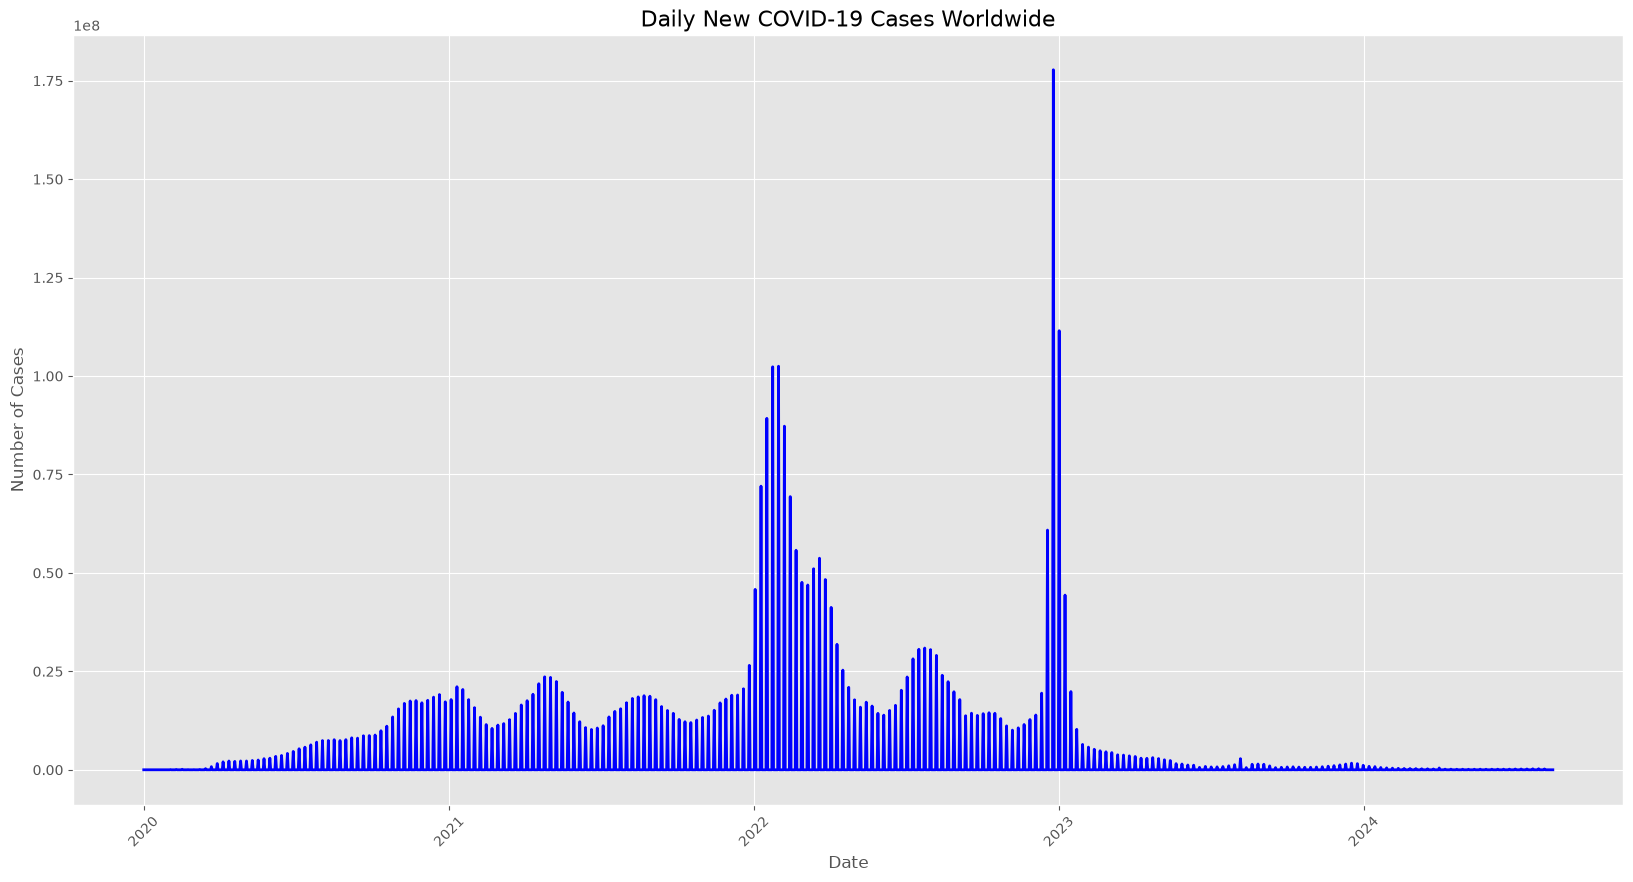

In [22]:
#Daily New Cases Trend#
daily_cases = df.groupby('date')['new_cases'].sum().reset_index()
plt.figure(figsize=(20, 10))
plt.plot(daily_cases['date'], daily_cases['new_cases'], color='blue', linewidth=2)
plt.title('Daily New COVID-19 Cases Worldwide', fontsize=16)    
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.xticks(rotation=45)
plt.show()

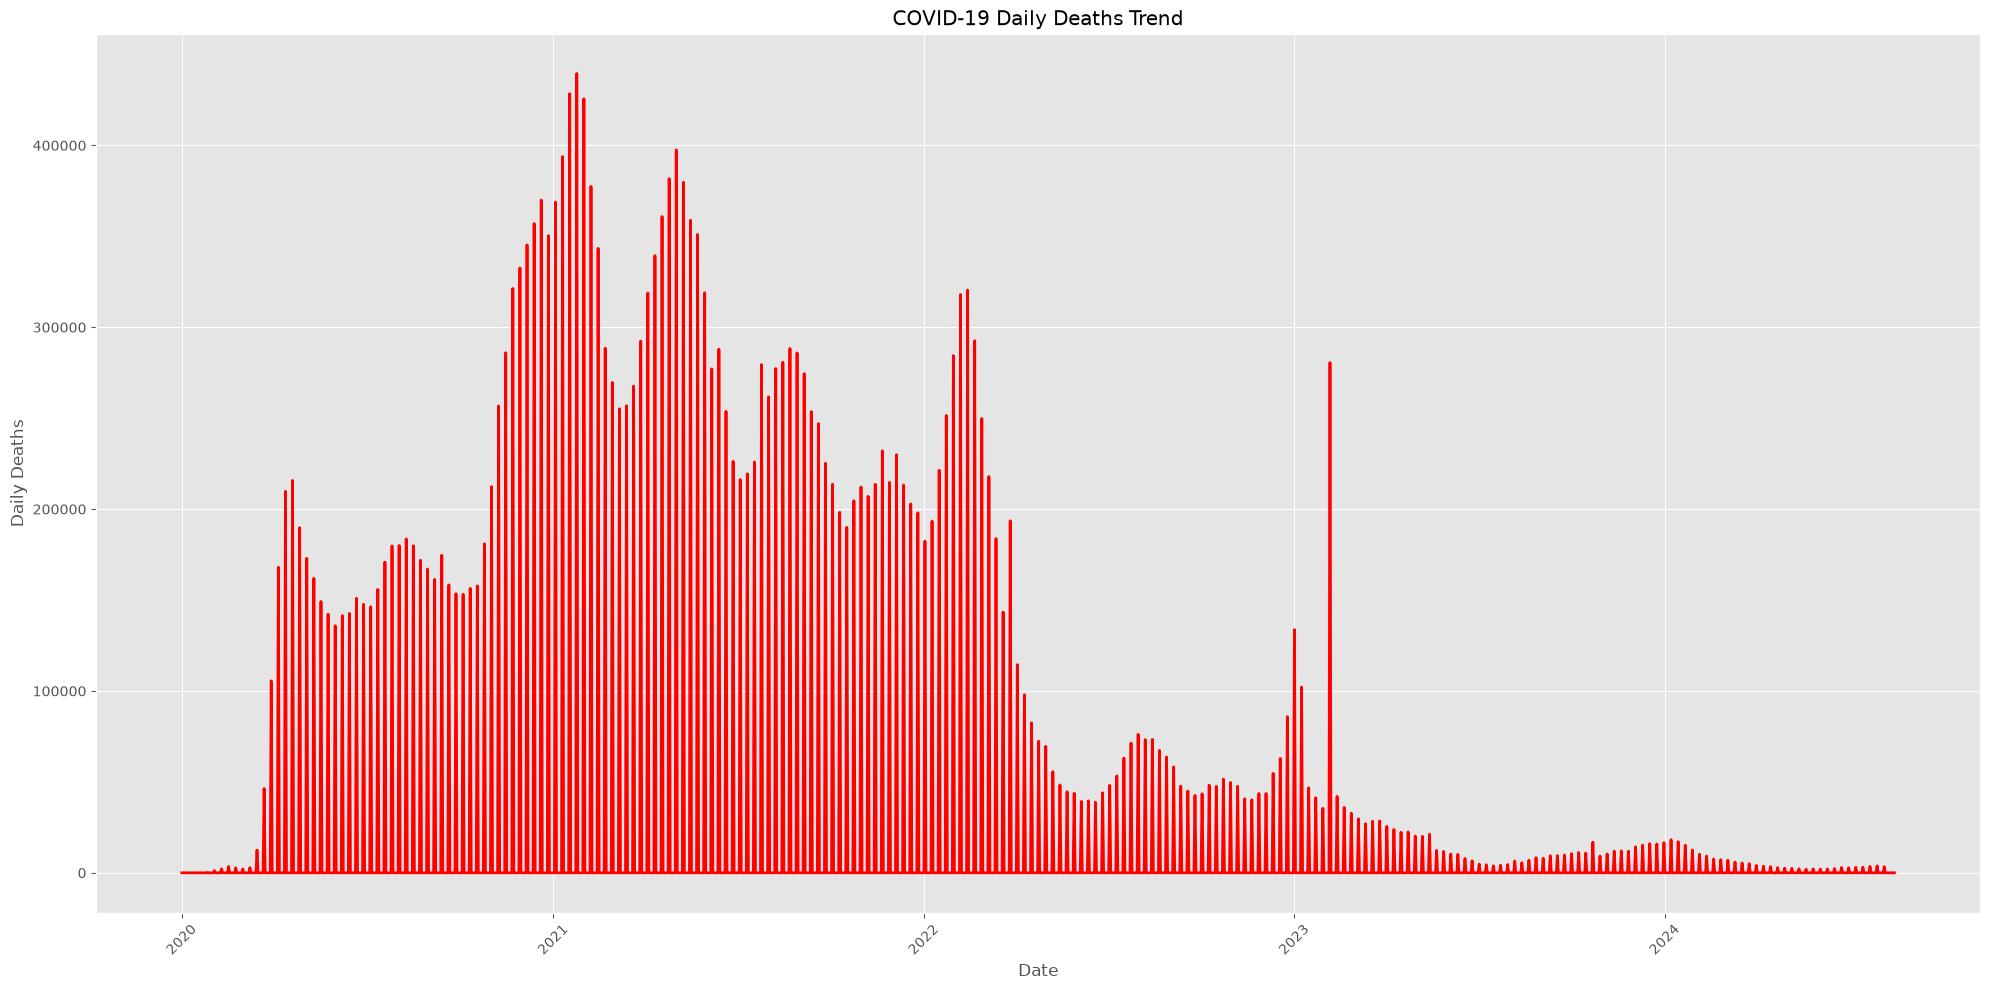

In [23]:
#Daily Death Trend#
daily_deaths=df.groupby('date')['new_deaths'].sum().reset_index()
plt.figure(figsize=(20,10))
plt.plot(daily_deaths['date'], daily_deaths['new_deaths'], color='red', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Daily Deaths')
plt.title('COVID-19 Daily Deaths Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

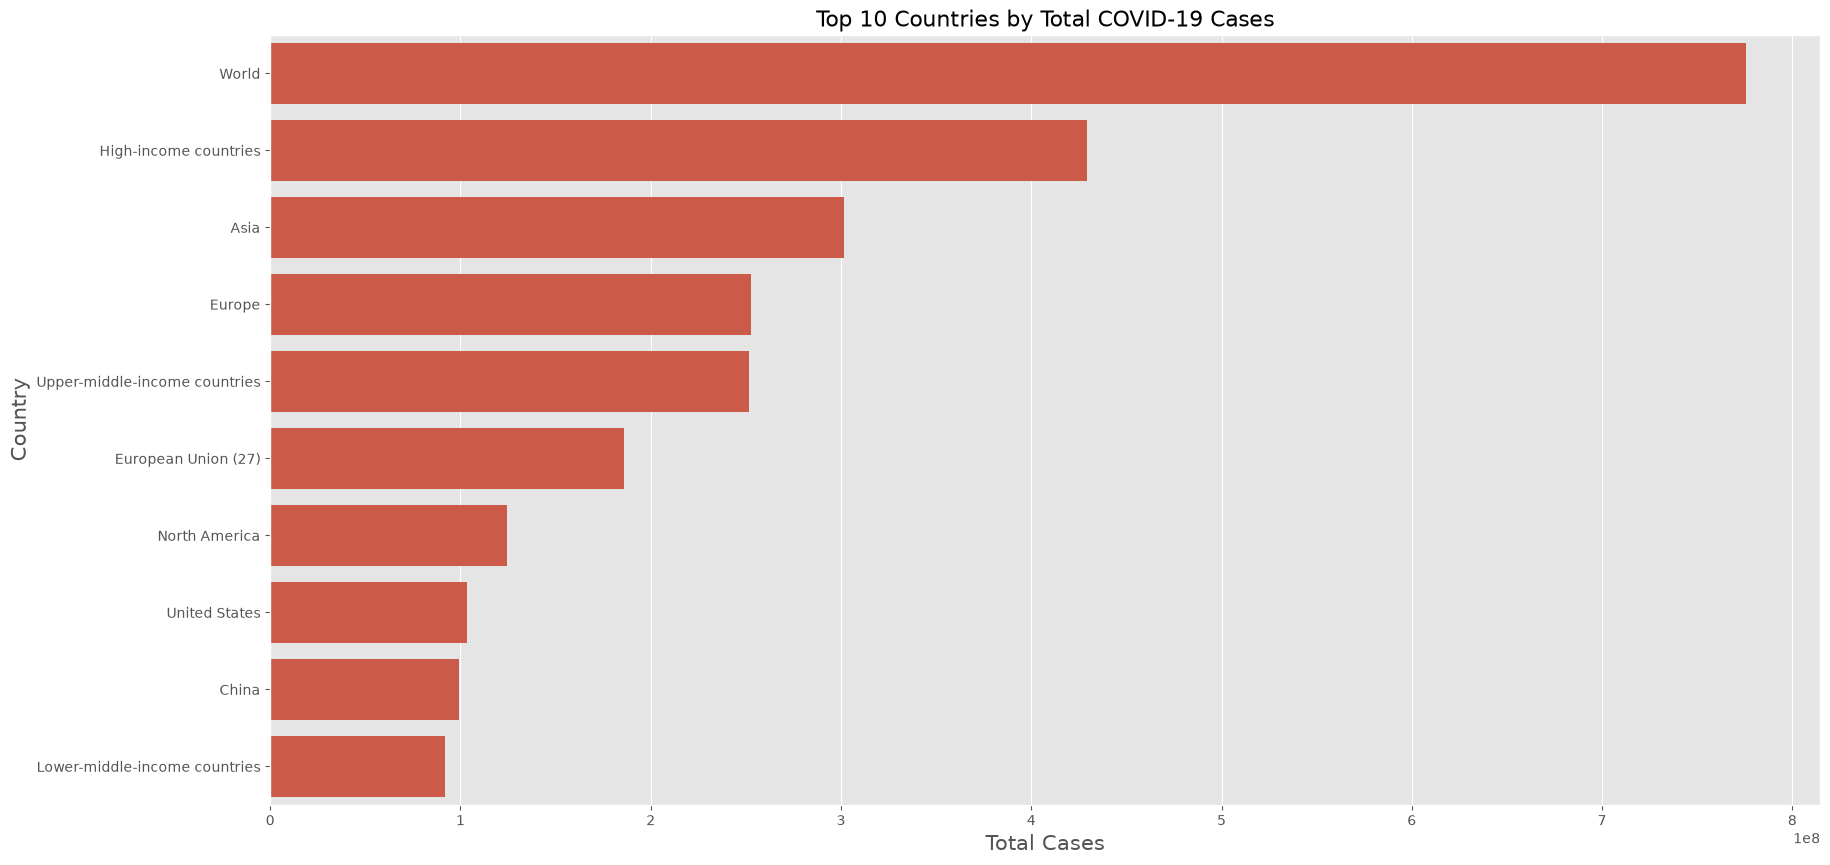

In [24]:
# Top 10 Countries by Total Cases#
total_cases =( df.groupby('location')['total_cases'].max().sort_values(ascending=False).head(10))
plt.figure(figsize=(20,10))
sns.barplot(x=total_cases.values,y=total_cases.index)
plt.title('Top 10 Countries by Total COVID-19 Cases', fontsize=16)
plt.xlabel('Total Cases', fontsize=15)
plt.ylabel('Country', fontsize=15)  
plt.show()

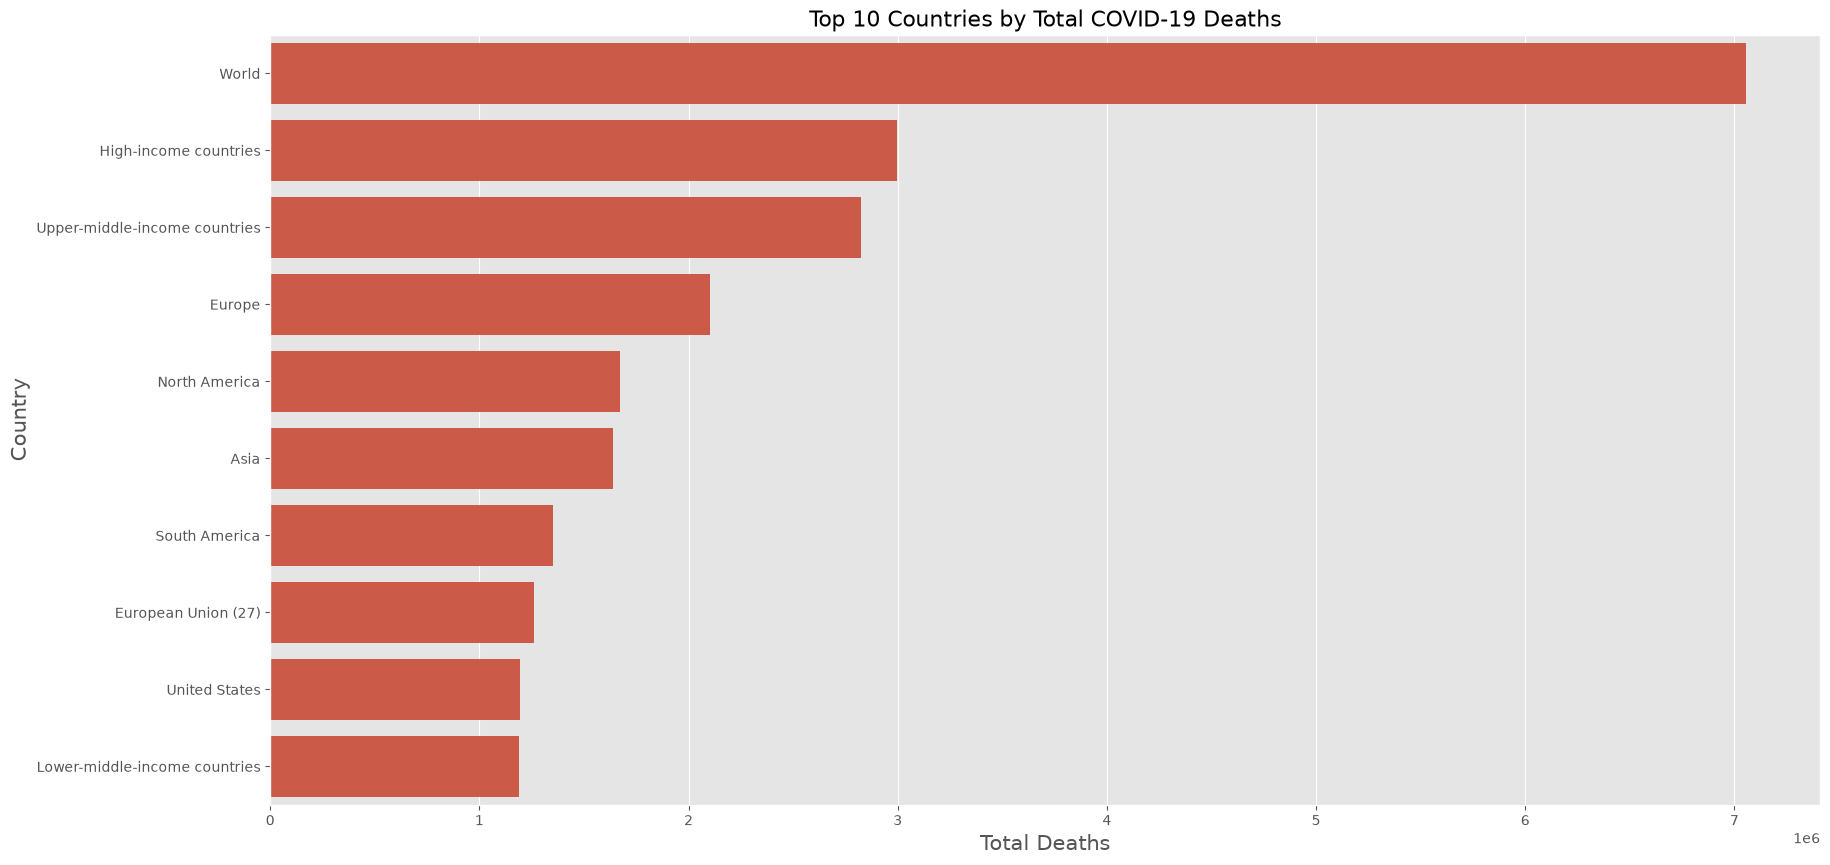

In [25]:
#Top 10 Countries by Total Deaths#
total_deaths = df.groupby('location')['total_deaths'].max().sort_values(ascending=False).head(10)
plt.figure(figsize=(20,10))         
sns.barplot(x=total_deaths.values,y=total_deaths.index)
plt.title('Top 10 Countries by Total COVID-19 Deaths', fontsize=16)
plt.xlabel('Total Deaths', fontsize=15)
plt.ylabel('Country', fontsize=15)  
plt.show()

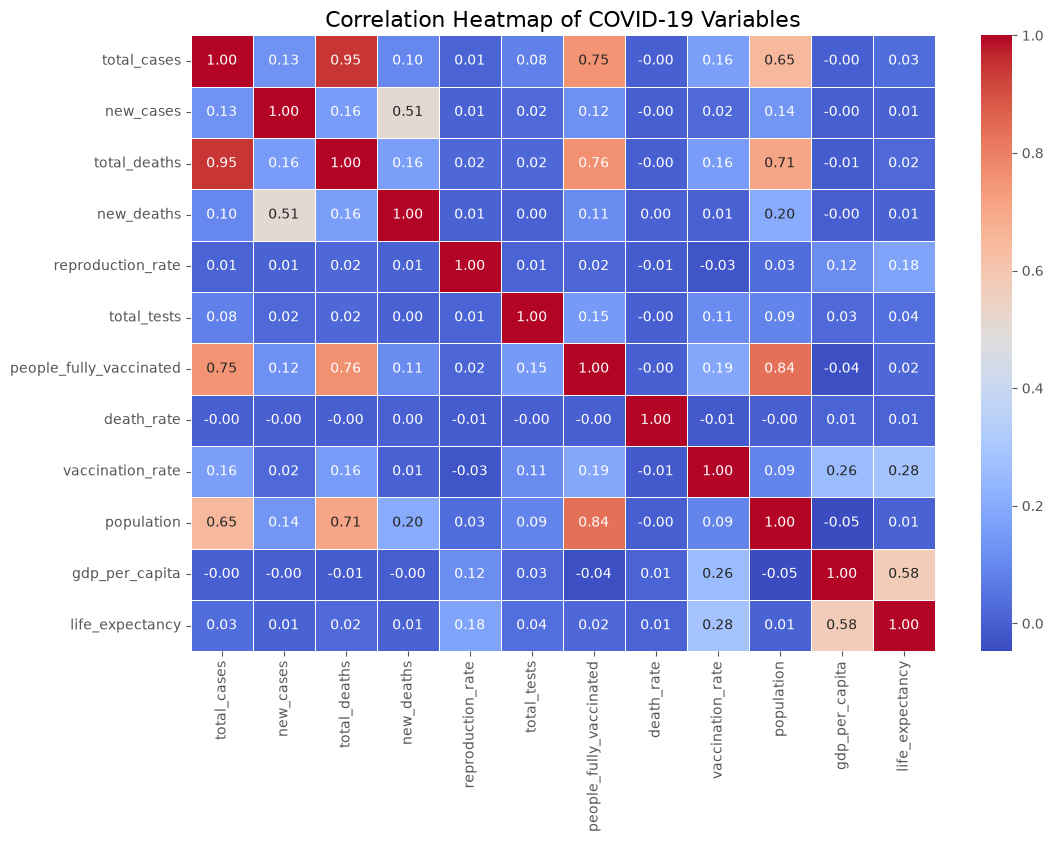

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select important numerical columns
heatmap_data = df[
    [
        'total_cases',
        'new_cases',
        'total_deaths',
        'new_deaths',
        'reproduction_rate',
        'total_tests',
        'people_fully_vaccinated',
        'death_rate',
        'vaccination_rate',
        'population',
        'gdp_per_capita',
        'life_expectancy'
    ]
]

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of COVID-19 Variables", fontsize=16)
plt.show()

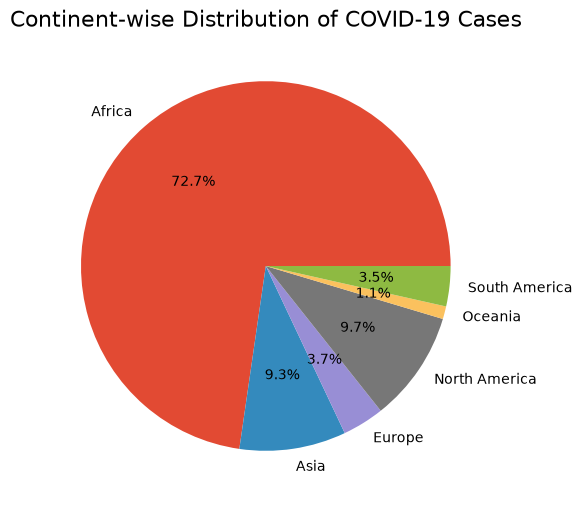

In [27]:
#Which continent contributed the most cases#
from cProfile import label

continent_cases = (df.groupby('continent')['total_cases'].max())
plt.figure(figsize=(16,6))
plt.pie(continent_cases, labels=continent_cases.index, autopct='%1.1f%%')
plt.title('Continent-wise Distribution of COVID-19 Cases', fontsize=16)
plt.show()

In [28]:
import plotly.express as px

world = (
    df.groupby('location', as_index=False)['total_cases']
      .max()
)

fig = px.choropleth(
    world,
    locations='location',
    locationmode='country names',
    color='total_cases',
    hover_name='location',
    color_continuous_scale='Reds',
    title='Global COVID-19 Total Cases'
)

fig.show()

C:\Users\amers\AppData\Local\Temp\ipykernel_22300\1205603097.py:8: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


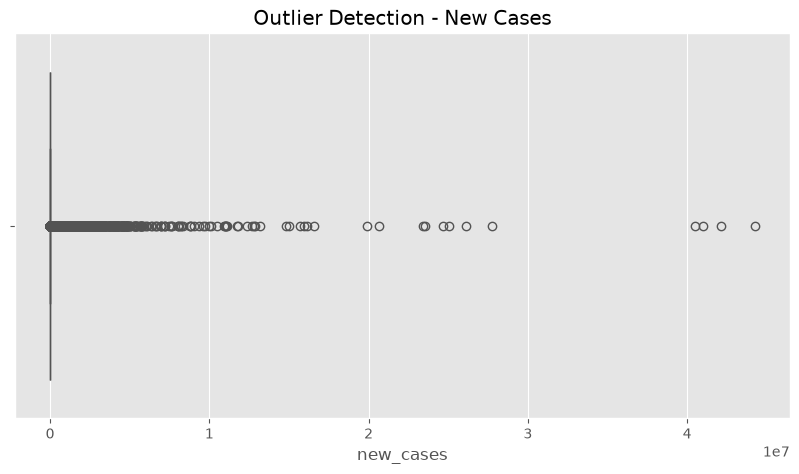

In [29]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['new_cases'])

plt.title("Outlier Detection - New Cases")

plt.show()

In [30]:
df.to_csv("covid19_cleaned.csv", index=False)

print("✅ Data Cleaning Completed Successfully!")

✅ Data Cleaning Completed Successfully!


In [31]:
import mysql.connector

try:
    conn = mysql.connector.connect(
        host="localhost",
        user="root",
        password="password",
        database="covid_analysis"
    )

    if conn.is_connected():
        print("✅ Connected to MySQL Successfully!")

except mysql.connector.Error as e:
    print("❌ Error:", e)

finally:
    if 'conn' in locals() and conn.is_connected():
        conn.close()
        print("🔒 Connection Closed")

✅ Connected to MySQL Successfully!
🔒 Connection Closed
